<a href="https://colab.research.google.com/github/ykim68ncstate/ST554-homwork_Yujin-Kim/blob/main/HW8/ST554_HW8_YujinKim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ST 554 Analysis of BigData - HW8
Name: Yujin Kim

Course: ST 554 (601) Spring 2026 Analysis of Big Data

Assignment: Homework #8

In [127]:
#import library
import pandas as pd
import numpy as np

# Previous Work - Homework 7
In Homework 7, I developed several regression and classification models using the wine dataset. For the regression task, I used multiple linear regression models with different sepcifications, including simple, interaction, polynomial, and selected feature models. I also applied regularization techniques such as LASSO, Ridge, and Elastic Net to improve model performance.

For  the classification task, I used logistic regression models with similar variations in predictors, including interaction and polynomial terms. Model performance was evaluated using RMSE and MAE for regression, and log-loss and accuracy for classification.

## 1. Read in and Combine Data
In this section, I load the red and white wine datasets and combine them into one dataframe. I also create a binary variable called `type` to indicate wine type, where red wine is coded as 0 and wine is coded as 1.

### (1) Read Data

* Read in the `winequality-red.csv` and `winequality-white.csv` files available on the.[UCI machine learning repository site](https://archive.ics.uci.edu/dataset/186/wine+quality).


In [128]:
red = pd.read_csv("winequality-red.csv", sep=";") #;로 구분되어 있음
white = pd.read_csv("winequality-white.csv", sep=";")

In [129]:
print("Red shape:", red.shape)
print("White shape", white.shape)

red.head()

Red shape: (1599, 12)
White shape (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [130]:
white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### (2) Merge data
* Combine these two datasets and create a new variable that represents the type of wine (red or white)

In [131]:
#Create wine_type variable
red["type"] = 0 #red
white["type"] = 1 # white

In [132]:
# Merge data
wine = pd.concat([red, white], axis=0, ignore_index=True) #created type column 0 is red, 1 is white

print(wine.shape)
wine.head()

(6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [133]:
#check number of red and white
wine["type"].value_counts()

,count
type,
1,4898
0,1599


### (3) Check basic data information

In [134]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [135]:
wine.describe() #descriptive statistics summary

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.753886
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,1.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,1.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


In [136]:
wine.isna().sum() # count the number of missing values

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


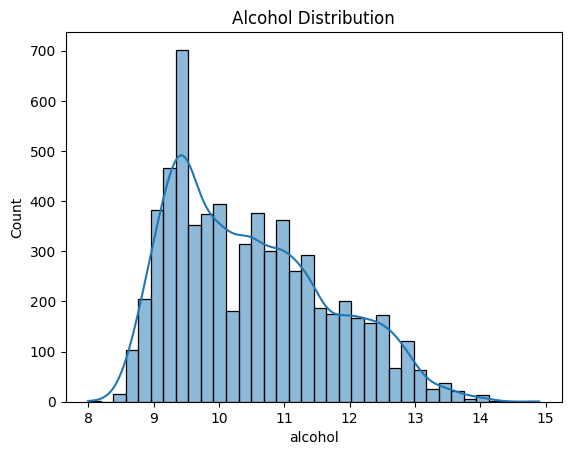

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(wine["alcohol"], kde=True)
plt.title("Alcohol Distribution")
plt.show()

The combined dataset contains both red and white wines and includes the physicochemical measurements provided in the original dataset. I checked the summary statistics and missing values to confirm that the data were loaded correctly and are ready for modeling.

## 2. Split the Data

* Split up the data set into a training and test set. For this, I want you to use stratified sampling to make sure that you have a similar proportion of white and red wines in the training and test sets. This can be done with the `train_test_split()` function ([see the help](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)).

I split the data into training and test sets. I use stratified sampling based on wine type so that the proportions of red and white wines remain similar in both sets.

In [138]:
X = wine.drop(["alcohol", "type"], axis=1)

y_reg = wine["alcohol"] #regression target
y_clf = wine["type"] #classification target

In [139]:
from sklearn.model_selection import train_test_split
#Stratified split >> stratify는 classification 기준으로 해야 함
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size = 0.2, random_state = 42, stratify = y_clf)

In [140]:
#split check
print("Train distribution:")
print(y_clf_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_clf_test.value_counts(normalize=True))

Train distribution:
type
1    0.753896
0    0.246104
Name: proportion, dtype: float64

Test distribution:
type
1    0.753846
0    0.246154
Name: proportion, dtype: float64


the class proportions in the training and test sets are very similar, which confirms that stratified sampling worked as intended. [Split data into train and test sets](https://www.geeksforgeeks.org/machine-learning/multiple-linear-regression-with-scikit-learn/)

## 3. Regression Task (alcohol as Response)

* Fit four different multiple linear regression models.

### (1) Train Models: Multiple linaer regression
* Fit four different multiple linear regression models.


I first fit a simple multiple linear regression model using all available predictors. I evaluate the model using 5 fold cross validation and summarize performance with RMSE. [Cross-validation score](https://scikit-learn.org/stable/modules/cross_validation.html)

In [141]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

#simple MLR model1

model1 = LinearRegression()

cv_scores1 = cross_val_score(model1, X_train, y_reg_train, cv = 5, scoring = 'neg_mean_squared_error')

rmse1 = np.sqrt(-cv_scores1.mean()) #cv_scores는 음수이기 때문에 양수로 바꿔야함
rmse1

np.float64(0.5477767685928024)

  * At least one should include interaction terms

I fit a regression model with interaction terms. Interaction terms allow the effect of one predictor to depend on the value of another predictor. I create these terms using `PolynomialFeatures` with `interaction_only=Ture`.

In [142]:
#include interaction model2
from sklearn.preprocessing import PolynomialFeatures

interaction = PolynomialFeatures(degree = 2, interaction_only = True, include_bias = False)

X_train_inter = interaction.fit_transform(X_train)
X_test_inter = interaction.transform(X_test)

#cross validation
model2 = LinearRegression()

cv_scores2 = cross_val_score(model2, X_train_inter, y_reg_train, cv = 5, scoring = 'neg_mean_squared_error')

rmse2 = np.sqrt(-cv_scores2.mean())
rmse2

np.float64(0.527894138996566)

This model is more flexible than the simple linear regression model because it allows predictors to work jointly rather than only additively.

  * At least one should include some polynomial terms (you may want to standardize your predictors but that is up to you)

I fit a polynomial regression model by adding second degree terms. This allows the model to capture nonlinear relationships between the predictors and alcohol.

In [143]:
#include polynomial model3
poly = PolynomialFeatures(degree = 2, include_bias = False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model3 = LinearRegression()

cv_scores3 = cross_val_score(model3, X_train_poly, y_reg_train, cv = 5, scoring = 'neg_mean_squared_error')

rmse3 = np.sqrt(-cv_scores3.mean())
rmse3

np.float64(0.4600075526681994)

* Fit four different multiple linear regression models. >>> add select feature model
I fit a simple regression model using only a selected subset of predictors. This provides a useful comparison against the larger and more flexible models.

In [144]:
#selected features model4
selected_features = ["density", "pH", "sulphates", "residual sugar", "chlorides"]

model4 = LinearRegression()

cv_scores4 = cross_val_score(model4, X_train[selected_features], y_reg_train, cv = 5, scoring = 'neg_mean_squared_error')

rmse4 = np.sqrt(-cv_scores4.mean())
rmse4

np.float64(0.8144646179394637)

  * Use CV to select your best MLR model

In [145]:
#results comparison
results = pd.DataFrame({"Model": ["Simple", "Interaction", "Polynomial", "Selected Features"],
                        "CV_RMSE": [rmse1, rmse2, rmse3, rmse4]})
results

,Model,CV_RMSE
0,Simple,0.547777
1,Interaction,0.527894
2,Polynomial,0.460008
3,Selected Features,0.814465


In [146]:
best_model_name = results.loc[results["CV_RMSE"].idxmin(), "Model"]
best_model_name

'Polynomial'

The polynomial model achieved the lowest RMSE, indicating the best performance among all models.
This suggests that nonlinear relationships between pedictors and alcohol are important. the interaction model also improved performance compared to the simple model, while the selected-features model performed the worst.

### (2) Train Models: LASSO
* Fit a LASSO model with a set of predictors of your choosing
  * Use at least five predictors
  * Use CV to select the tuning parameter

I fit a LASSO model using a selected set of predictors. Because regularized regression depends on the scale of the predictors, I standardize the training data first and apply the same transformation to the test data. this follows the lecture guidance for regularized regression.

In [147]:
# select predictor
reg_features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "density",
    "pH"]

X_train_reg = X_train[reg_features]
X_test_reg = X_test[reg_features]

In [148]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg)
X_test_scaled = scaler.transform(X_test_reg)


In [149]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

lasso_model = LassoCV(cv = 5, random_state = 42)
lasso_model.fit(X_train_scaled, y_reg_train)


lasso_pred = lasso_model.predict(X_test_scaled)

lasso_rmse = np.sqrt(mean_squared_error(y_reg_test, lasso_pred))
lasso_mae = mean_absolute_error(y_reg_test, lasso_pred)

print("LASSO RMSE:", lasso_rmse)
print("LASSO MAE:", lasso_mae)
print("Best alpha:", lasso_model.alpha_)

LASSO RMSE: 0.5910610880091111
LASSO MAE: 0.44091834237210625
Best alpha: 0.0008255721135897018


결과해석

### (3) Train Models: Ridge Regression
* Fit a Ridge Regression model with a set of predictors of your choosing
  * Use at least five predictors
  * Use CV to select the tuning parameter

I fit a Ridge regression model. Unlike LASSO, Ridge shrinks coefficients but does not typically set them exactly to zero, which can be useful when many predictors contribute the response.

In [150]:
from sklearn.linear_model import RidgeCV

ridge_alphas = np.logspace(-3, 3, 100)

ridge_model = RidgeCV(alphas = ridge_alphas, cv = 5)
ridge_model.fit(X_train_scaled, y_reg_train)

ridge_pred = ridge_model.predict(X_test_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_reg_test, ridge_pred))
ridge_mae = mean_absolute_error(y_reg_test, ridge_pred)

print("Ridge RMSE:", ridge_rmse)
print("Ridge MAE:", ridge_mae)
print("Best alpha:", ridge_model.alpha_)

Ridge RMSE: 0.5909965994782305
Ridge MAE: 0.4409952815160599
Best alpha: 3.7649358067924674


### (4) Train:Models: Elastic Net
* Fit an Elastic Net model with a set of predictors of your choosing
  * Use at least five predictors
  * Use CV to select the tuning parameters

I fit an Elastic Net model, which combines the L1 penalty from LASSO and the L2 penalty from Ridge. Cross validation is used to choose both the penalty strength and the mixing ratio.

In [151]:
from sklearn.linear_model import ElasticNetCV

elastic_model = ElasticNetCV(
    cv = 5, random_state = 42, l1_ratio = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
)

elastic_model.fit(X_train_scaled, y_reg_train)

elastic_pred = elastic_model.predict(X_test_scaled)
elastic_rmse = np.sqrt(mean_squared_error(y_reg_test, elastic_pred))
elastic_mae = mean_absolute_error(y_reg_test, elastic_pred)

print("Elastic Net RMSE:", elastic_rmse)
print("Elastic Net MAE:", elastic_mae)
print("Best alpha:", elastic_model.alpha_)
print("Best l1_ratio:", elastic_model.l1_ratio_)

Elastic Net RMSE: 0.5910610880091111
Elastic Net MAE: 0.44091834237210625
Best alpha: 0.0008255721135897018
Best l1_ratio: 1.0


The test set comparison shows how well the four selected regression models generalize to unseen data. I compare them using both RMSE and MAE, where lower values indicate better predictive performance.

In [152]:
regularized_results = pd.DataFrame({
    "Model": ["LASSO", "Ridge", "Elastic Net"],
    "RMSE": [lasso_rmse, ridge_rmse, elastic_rmse],
    "MAE": [lasso_mae, ridge_mae, elastic_mae]
})

regularized_results

,Model,RMSE,MAE
0,LASSO,0.591061,0.440918
1,Ridge,0.590997,0.440995
2,Elastic Net,0.591061,0.440918


All three regularized models (LASSO, Ridge, and Elastic Net) showed very similar performance.
Ridge performed slightly better with the lowest RMSE, but the differences between the models are minimal, suggesting that the choice of regularization method does not significantly impact performance for this dataset.

### (5) Test Models
* Using your four selected models, compare their performance on the test set.
  * Do so using RMSE as your model metric
  * Do so using MAE as your model metric

In [153]:
#fit on training data
model1.fit(X_train, y_reg_train)
model2.fit(X_train_inter, y_reg_train)
model3.fit(X_train_poly, y_reg_train)
model4.fit(X_train[selected_features], y_reg_train)

LinearRegression()

In [154]:
# predict test
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test_inter)
pred3 = model3.predict(X_test_poly)
pred4 = model4.predict(X_test[selected_features])

In [155]:
#calculate RMSE / MAE
rmse1 = np.sqrt(mean_squared_error(y_reg_test, pred1))
mae1 = mean_absolute_error(y_reg_test, pred1)

rmse2 = np.sqrt(mean_squared_error(y_reg_test, pred2))
mae2 = mean_absolute_error(y_reg_test, pred2)

rmse3 = np.sqrt(mean_squared_error(y_reg_test, pred3))
mae3 = mean_absolute_error(y_reg_test, pred3)

rmse4 = np.sqrt(mean_squared_error(y_reg_test, pred4))
mae4 = mean_absolute_error(y_reg_test, pred4)

In [156]:
#comparison
test_results = pd.DataFrame({
    "Model": ["Simple", "Interaction", "Polynomial", "Selected Features"],
    "RMSE": [rmse1, rmse2, rmse3, rmse4],
    "MAE": [mae1, mae2, mae3, mae4]
})

test_results

,Model,RMSE,MAE
0,Simple,0.514965,0.394164
1,Interaction,0.494070,0.358770
2,Polynomial,0.473236,0.342595
3,Selected Features,0.831830,0.642490


In [157]:
#select best model
best_model = test_results.loc[test_results["RMSE"].idxmin()]
best_model

,2
Model,Polynomial
RMSE,0.473236
MAE,0.342595


The polynomial model achieved the lowest RMSE and MSE on the test set, indicating the best performance.
This confirms that nonlinear relationships between predictors and alcohol improve prediction accuracy. The interaction model also performed better than the simple model, while the selected features model performed the worst.

## 4. Classification Task (Wine Type as Response)
* Repeat the training and testing done previously but use logistic regression models.
* Use log-loss or negative log-loss as your metric for choosing models during the training process
* During the testing portion, compare your models on both log-loss and accuracy


For the classification task, I use wine type as the response variable and fit logistic regression models. Logistic regression is appropriate here because the response is binary.

### (1) Train Models: Logistic regression
* Fit four different logistic regression models.

I begin with a simple logistic regression model using all predictors. During training, I use cross-validated log-loss as the model selection metric because it evaluates predicted probabilities rather than only hard class labels.

In [158]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
#simple logistic regression model1
log_model1 = LogisticRegression(max_iter=5000)

cv_logloss1 = -cross_val_score(log_model1, X_train, y_clf_train, cv = 5, scoring="neg_log_loss").mean()

cv_logloss1

np.float64(0.06684023097132455)

I fit more flexible logistic regression models with interaction terms and polynomial terms. These transformed features allow the classification boundary to become more flexible. The lecture notes show that logistic regression can be extended in this way using `PolynomialFeatures`.

In [159]:
#interaction model2
interaction = PolynomialFeatures(degree = 2, interaction_only = True, include_bias = False)

X_train_inter = interaction.fit_transform(X_train)
X_test_inter = interaction.transform(X_test)

#Cross validation
log_model2 = LogisticRegression(max_iter = 5000)

cv_logloss2 = -cross_val_score(log_model2, X_train_inter, y_clf_train, cv=5, scoring = "neg_log_loss").mean()
cv_logloss2

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

np.float64(0.05422805409713508)

In [160]:
#Polynomial model3
poly = PolynomialFeatures(degree = 2, include_bias = False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

#Cross validation
log_model3= LogisticRegression(max_iter = 5000)

cv_logloss3 = -cross_val_score(log_model3, X_train_poly, y_clf_train, cv = 5, scoring = "neg_log_loss").mean()
cv_logloss3

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

np.float64(0.06957530841267068)

In [161]:
#selected features model4
clf_features = ["density", "fixed acidity", "volatile acidity", "citric acid", "chlorides"]

log_model4 = LogisticRegression(max_iter = 5000)

cv_logloss4 = -cross_val_score(log_model4, X_train[clf_features], y_clf_train, cv = 5, scoring="neg_log_loss").mean()

cv_logloss4

np.float64(0.22191884750911756)

On the test set, I compare the logistic regression models using both log-loss and accuracy. Log-loss evaluates the predicted probabilities, while accuracy measures the proportion of correctly classified wines.

In [162]:
clf_cv_results = pd.DataFrame({
    "Model": ["Simple", "Interaction", "Polynomial", "Selected Features"],
    "CV_LogLoss": [cv_logloss1, cv_logloss2, cv_logloss3, cv_logloss4]
})

clf_cv_results

,Model,CV_LogLoss
0,Simple,0.066840
1,Interaction,0.054228
2,Polynomial,0.069575
3,Selected Features,0.221919


The interaction model achieved the lowest log-loss, indicating the best performance among the models.
This suggests that interactions between predictors improve classification performance. In contrast, the polynomial model did not improve performance, and the selected features model performed the worst.

### (2) Test Models
* Using your four selected models, compare their performance on the test set.
  * Do so using RMSE as your model metric
  * Do so using MAE as your model metric

In [163]:
#model fit
log_model1.fit(X_train, y_clf_train)
log_model2.fit(X_train_inter, y_clf_train)
log_model3.fit(X_train_poly, y_clf_train)
log_model4.fit(X_train[clf_features], y_clf_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LogisticRegression(max_iter=5000)

In [164]:
#predict
proba1 = log_model1.predict_proba(X_test)
pred1 = log_model1.predict(X_test)

proba2 = log_model2.predict_proba(X_test_inter)
pred2 = log_model2.predict(X_test_inter)

proba3 = log_model3.predict_proba(X_test_poly)
pred3 = log_model3.predict(X_test_poly)

proba4 = log_model4.predict_proba(X_test[clf_features])
pred4 = log_model4.predict(X_test[clf_features])

In [165]:
#log-loss and accuracy
from sklearn.metrics import log_loss, accuracy_score

test_logloss1 = log_loss(y_clf_test, proba1)
test_acc1 = accuracy_score(y_clf_test, pred1)

test_logloss2 = log_loss(y_clf_test, proba2)
test_acc2 = accuracy_score(y_clf_test, pred2)

test_logloss3 = log_loss(y_clf_test, proba3)
test_acc3 = accuracy_score(y_clf_test, pred3)

test_logloss4 = log_loss(y_clf_test, proba4)
test_acc4 = accuracy_score(y_clf_test, pred4)

In [166]:
clf_test_results = pd.DataFrame({
    "Model": ["Simple", "Interaction", "Polynomial", "Selected Features"],
    "LogLoss": [test_logloss1, test_logloss2, test_logloss3, test_logloss4],
    "Accuracy": [test_acc1, test_acc2, test_acc3, test_acc4]
})

clf_test_results

,Model,LogLoss,Accuracy
0,Simple,0.052679,0.984615
1,Interaction,0.036221,0.989231
2,Polynomial,0.042502,0.986154
3,Selected Features,0.213203,0.922308


The interaction model achieved the lowest log-loss and highest accuracy on the test set, indicating the best performacne.
This confirms that interactions between predictors improve classification performance. The polynomial model showed moderate performance, while the selected features model performed the worst.

# Homework 8
In Homework 8, I extended the modeling approaches from Homework 7 by applying tree-based methods, including regression trees, classification trees, and random forests. The goal was to explore more flexible, non-linear models and compare their performance with the linear and logistic models developed previously.

For the regression task, alcohol content was used as the response variable, and model performance was evaluated using RMSE and MAE. For the classification task, wine type was used as the response variable, and models were evaluated using log-loss and accuracy. Cross validation was used to select tuning parameters for all tree-based models.

## 1. Regression Task (`alcohol` as Response)

### (1) Train Models
To begin the regression task, I fit a regression tree model using `alcohol` as the response variable. I selected six predictors from the wine dataset, satisfying the rquirement to use at least five predictors. I then used 5-fold cross validation to tune the regression tree hyperparameters `max_depth` and `min_samples_leaf`.

#### (a) Fit a regression tree

Instruction: Use at least five predictors, Use CV to select the tuning parameters (`max_depth` and `min_sample_leaf`)


In [167]:
#Use at least five predictors
tree_reg_features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "density",
]

In [168]:
#allocate variables in train/test
X_train_tree_reg = X_train[tree_reg_features]
X_test_tree_reg = X_test[tree_reg_features]

In [169]:
#select tuning parameter candidate
tree_reg_param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 2, 5, 10, 20]
}

In [170]:
#Use CV to select the tuning parameters
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

tree_reg = DecisionTreeRegressor(random_state = 42) #set regression tree model

tree_reg_cv = GridSearchCV( #train several combinations of max_depth and min_samples_leaf
    estimator = tree_reg,
    param_grid = tree_reg_param_grid,
    scoring = "neg_root_mean_squared_error",
    cv = 5,
    n_jobs = -1)

tree_reg_cv.fit(X_train_tree_reg, y_reg_train) #fit model

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
                         'min_samples_leaf': [1, 2, 5, 10, 20]},
             scoring='neg_root_mean_squared_error')

In [171]:
#Check CV result
tree_reg_cv_results = pd.DataFrame(tree_reg_cv.cv_results_)[
    ["param_max_depth", "param_min_samples_leaf", "mean_test_score", "rank_test_score"]
    ].sort_values("rank_test_score")

tree_reg_cv_results.head(10)

,param_max_depth,param_min_samples_leaf,mean_test_score,rank_test_score
38,None,10,-0.618466,1
33,10,10,-0.620928,2
32,10,5,-0.624914,3
39,None,20,-0.626803,4
37,None,5,-0.626807,5
34,10,20,-0.628548,6
28,8,10,-0.632929,7
27,8,5,-0.634473,8
29,8,20,-0.635535,9
31,10,2,-0.639377,10


In [172]:
# check best parameter
print("Best parameters:", tree_reg_cv.best_params_)
print("Best CV RMSE:", -tree_reg_cv.best_score_)

Best parameters: {'max_depth': None, 'min_samples_leaf': 10}
Best CV RMSE: 0.6184662594668858


The optimal value of `max_depth` selected by cross validation was `None`, indicating that the model performs best without restricting the depth of the tree. This suggests that a more complex tree structure improves predictive performance for this dataset.

#### (b) Fit a random forest model

Instruction: Use at least five predictors, Use CV to select the tuning parameter(s) (`max_features`, feel free to include others if you'd like)

I fit a random forest regression model using `alcohol` as the response variable. Isued the same set of predictors as in the regression tree model. To select the best random forest model, I used 5-fold cross validation and tuned `max_features` as required. I also include `min_samples_leaf` as an additional tuning parameter.

In [173]:
#Use same predictor with regression tree
X_trian_rf_reg = X_train[tree_reg_features]
X_test_rf_reg = X_test[tree_reg_features]

In [174]:
#set tuning parameter gird
rf_reg_param_grid = {
    "max_features": [2, 3, 4, 5, "sqrt", None],
    "min_samples_leaf": [1, 2, 5],
    "n_estimators": [200]
}

In [175]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(random_state = 42) #set regression tree model

rf_reg_cv = GridSearchCV( #train several combinations of max_depth and min_samples_leaf
    estimator = rf_reg,
    param_grid = rf_reg_param_grid,
    scoring = "neg_root_mean_squared_error",
    cv = 5,
    n_jobs = -1)

rf_reg_cv.fit(X_trian_rf_reg, y_reg_train) #fit model

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_features': [2, 3, 4, 5, 'sqrt', None],
                         'min_samples_leaf': [1, 2, 5], 'n_estimators': [200]},
             scoring='neg_root_mean_squared_error')

In [176]:
#Check CV result
rf_reg_cv_results = pd.DataFrame(rf_reg_cv.cv_results_)[
    ["param_max_features", "param_min_samples_leaf", "param_n_estimators", "mean_test_score", "rank_test_score"]
    ].sort_values("rank_test_score")

rf_reg_cv_results.head(10)

,param_max_features,param_min_samples_leaf,param_n_estimators,mean_test_score,rank_test_score
9,5,1,200,-0.479031,1
15,None,1,200,-0.479044,2
6,4,1,200,-0.479479,3
3,3,1,200,-0.483381,4
10,5,2,200,-0.485155,5
7,4,2,200,-0.486060,6
16,None,2,200,-0.486091,7
4,3,2,200,-0.490605,8
12,sqrt,1,200,-0.494339,9
0,2,1,200,-0.494339,9


In [177]:
# check best parameter
print("Best parameters:", rf_reg_cv.best_params_)
print("Best CV RMSE:", -rf_reg_cv.best_score_)

Best parameters: {'max_features': 5, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV RMSE: 0.4790311934555767


### (2) Test Models
Instruction: Using your two selected models, compare their performance on the test set including a comparison
to your models from homework 7!
* Do so using RMSE as your model metric
* Do so using MAE as your model metric

In [178]:
#-----------regression tree & random forest--------------#
# Best models
best_tree = tree_reg_cv.best_estimator_
best_rf = rf_reg_cv.best_estimator_

In [179]:
#prediction
tree_pred = best_tree.predict(X_test_tree_reg)
rf_pred = best_rf.predict(X_test_rf_reg)

In [180]:
#calculate RMSE
tree_rmse = np.sqrt(mean_squared_error(y_reg_test, tree_pred))
rf_rmse = np.sqrt(mean_squared_error(y_reg_test, rf_pred))

In [181]:
#calculate MAE
tree_mae = mean_absolute_error(y_reg_test, tree_pred)
rf_mae = mean_absolute_error(y_reg_test, rf_pred)

In [182]:
reg_results = pd.DataFrame({
    "Model": ["Regression Tree", "Random Forest"],
    "RMSE": [tree_rmse, rf_rmse],
    "MAE": [tree_mae, rf_mae]
})
reg_results

,Model,RMSE,MAE
0,Regression Tree,0.621693,0.440928
1,Random Forest,0.474352,0.310330


In [183]:
#----------Comparison to other models--------#
##merge all models
hw7_reg_results = pd.concat(
    [test_results[["Model", "RMSE", "MAE"]],
     regularized_results[["Model", "RMSE", "MAE"]]],
    axis = 0,
    ignore_index = True
)

In [184]:
#add results
all_reg_results = pd.concat(
    [hw7_reg_results, reg_results],
    axis = 0,
    ignore_index = True
)

In [185]:
#sort the results
all_reg_results.sort_values("RMSE")

,Model,RMSE,MAE
2,Polynomial,0.473236,0.342595
8,Random Forest,0.474352,0.310330
1,Interaction,0.494070,0.358770
0,Simple,0.514965,0.394164
5,Ridge,0.590997,0.440995
6,Elastic Net,0.591061,0.440918
4,LASSO,0.591061,0.440918
7,Regression Tree,0.621693,0.440928
3,Selected Features,0.831830,0.642490


The polynomial model achieved the lowest RMSE, with the random forest performing nearly as well. Although their RMSE values are similar, the random forest had the lowest MAE, indicating more stable predictions.

The regression tree performed worse, likely due to high variance, and the regularized linear models also showed relatively poor performance. Overall models that capture non-linear relationships, such as polynomial regression and random forests, performaed best.

**Results:**

The polynomial regression model achieved the lowest RMSE, with the random forest performing nearly as well. The difference between the two models was minimal, indicating that both approaches provide strong predictive performance. However, the random forest achieved the lowest MAE, suggesting that it produces more stable predictions on average.

The regression tree performed worse than both linear and ensembel methods, likely due to its high variance. In addition, the regularized linear models (LASSO, Ridge, and Elastic Net) showed relatively poor performance, indicating that simple linear assumptions may not sufficiently capture the underlying relationships in the data.

## 2. Classification Task (Wine Type as Response)

### (1) Train Models

#### (a) Fit a classification tree
Instruction: Repeat the training and testing done previously but use classification trees and random forests with classification trees.
* Use log-loss or negative log-loss as your metric for choosing models during the training process

In [186]:
#Use at least five predictors
tree_clf_features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "density"
]

In [187]:
#allocate variables in train/test
X_train_tree_clf = X_train[tree_clf_features]
X_test_tree_clf = X_test[tree_clf_features]

In [188]:
#build tuning parameter grid
tree_clf_param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 2, 5, 10, 20]
}

In [189]:
#Use CV to select the tuning parameters
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state = 42)

tree_clf_cv = GridSearchCV(
    estimator = tree_clf,
    param_grid = tree_clf_param_grid,
    scoring = "neg_log_loss", #use negative log-loss
    cv = 5,
    n_jobs = -1
)

tree_clf_cv.fit(X_train_tree_clf, y_clf_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5, 6, 8, 10, None],
                         'min_samples_leaf': [1, 2, 5, 10, 20]},
             scoring='neg_log_loss')

In [190]:
#Check CV result
tree_clf_cv_results = pd.DataFrame(tree_clf_cv.cv_results_)[
    ["param_max_depth", "param_min_samples_leaf", "mean_test_score", "rank_test_score"]
    ].sort_values("rank_test_score")

tree_clf_cv_results.head(10)

,param_max_depth,param_min_samples_leaf,mean_test_score,rank_test_score
14,4,20,-0.131155,1
19,5,20,-0.155870,2
9,3,20,-0.158902,3
12,4,5,-0.161790,4
11,4,2,-0.175493,5
10,4,1,-0.182824,6
13,4,10,-0.183090,7
17,5,5,-0.183206,8
8,3,10,-0.183344,9
5,3,1,-0.183344,9


In [191]:
print("Best parameters:", tree_clf_cv.best_params_)
print("Best CV Log-Loss:", -tree_clf_cv.best_score_)

Best parameters: {'max_depth': 4, 'min_samples_leaf': 20}
Best CV Log-Loss: 0.13115505425591661


The selected classification tree has a relatively shallow depth and a large minimum leaf size, indicating that a simpler and more stable model provides better probability predictions under the log-loss metric.

#### (b) Fit a random forest model

In [192]:
#allocate variables in train/test
X_train_rf_clf = X_train[tree_clf_features]
X_test_rf_clf = X_test[tree_clf_features]

In [193]:
#build tuning parameter grid
rf_clf_param_grid = {
    "max_features": [2, 3, 4, 5, "sqrt", None],
    "min_samples_leaf": [1, 2, 5],
    "n_estimators": [200]
}

In [194]:
#Use CV to select the tuning parameters
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state = 42)

rf_clf_cv = GridSearchCV(
    estimator = rf_clf,
    param_grid = rf_clf_param_grid,
    scoring = "neg_log_loss",
    cv = 5,
    n_jobs = -1
)

rf_clf_cv.fit(X_train_rf_clf, y_clf_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_features': [2, 3, 4, 5, 'sqrt', None],
                         'min_samples_leaf': [1, 2, 5], 'n_estimators': [200]},
             scoring='neg_log_loss')

In [195]:
rf_clf_cv_results = pd.DataFrame(rf_clf_cv.cv_results_)[
    ["param_max_features", "param_min_samples_leaf", "param_n_estimators", "mean_test_score", "rank_test_score"]
].sort_values("rank_test_score")

rf_clf_cv_results.head(10)

,param_max_features,param_min_samples_leaf,param_n_estimators,mean_test_score,rank_test_score
3,3,1,200,-0.070726,1
4,3,2,200,-0.074084,2
1,2,2,200,-0.075180,3
13,sqrt,2,200,-0.075180,3
8,4,5,200,-0.076206,5
12,sqrt,1,200,-0.077081,6
0,2,1,200,-0.077081,6
2,2,5,200,-0.078131,8
14,sqrt,5,200,-0.078131,8
9,5,1,200,-0.079337,10


In [196]:
print("Best parameters:", rf_clf_cv.best_params_)
print("Best CV Log-Loss:", -rf_clf_cv.best_score_)

Best parameters: {'max_features': 3, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV Log-Loss: 0.07072578074266057


The random forest selected `max_features = 3` and `min_samples_leaf = 1` indicating that a flexible model with feature randomness improves performance. The cross validated log-loss of 0.0707 is substantially lower than that of the classification tree, showing that the random forest provides significantly better probability predictions.

### (2) Test Models
Instruction: Using your two selected models, compare their performance on the test set including a comparison
to your models from homework 7!

In [197]:
#-----------classification tree & random forest--------------#
#best models
best_tree_clf = tree_clf_cv.best_estimator_
best_rf_clf = rf_clf_cv.best_estimator_

In [198]:
#predictions
tree_proba = best_tree_clf.predict_proba(X_test_tree_clf)
tree_pred = best_tree_clf.predict(X_test_tree_clf)

rf_proba = best_rf_clf.predict_proba(X_test_rf_clf)
rf_pred = best_rf_clf.predict(X_test_rf_clf)

In [199]:
#log-loss
tree_logloss = log_loss(y_clf_test, tree_proba)
rf_logloss = log_loss(y_clf_test, rf_proba)

In [200]:
#accuracy
tree_acc = accuracy_score(y_clf_test, tree_pred)
rf_acc = accuracy_score(y_clf_test, rf_pred)

In [201]:
#----------Comparison to other models--------#
clf_tree_results = pd.DataFrame({
    "Model": ["Classification Tree", "Random Forest"],
    "LogLoss": [tree_logloss, rf_logloss],
    "Accuracy": [tree_acc, rf_acc]
})

clf_tree_results

,Model,LogLoss,Accuracy
0,Classification Tree,0.118716,0.952308
1,Random Forest,0.079495,0.982308


In [202]:
all_clf_results = pd.concat(
    [clf_test_results, clf_tree_results],
    axis = 0,
    ignore_index = True
)

all_clf_results.sort_values("LogLoss")

,Model,LogLoss,Accuracy
1,Interaction,0.036221,0.989231
2,Polynomial,0.042502,0.986154
0,Simple,0.052679,0.984615
5,Random Forest,0.079495,0.982308
4,Classification Tree,0.118716,0.952308
3,Selected Features,0.213203,0.922308


**results:**

The logistic regression models, particularly those including interaction and polynomial those including interaction and plynomial terms, achieved the lowest log-loss and highest accuracy. This indicates that they provide the most accurate probability predictions and classification performance for this dataset.

the random forest classifier performed better than the classification tree, significantly reducing log-loss and improving accuracy. However, it still did not outperform the best logistic regression models.